In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("customers.csv")
products = pd.read_csv("products.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
shipments = pd.read_csv("shipments.csv")
returns = pd.read_csv("returns.csv")

In [2]:
customers['gender'].unique()

<StringArray>
[nan, 'Female', 'Male', 'F', 'Unknown', 'M', 'female ']
Length: 7, dtype: str

In [3]:
customers['cleaned_gender'] = (
        customers['gender']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'm': 'male',
        'male': 'male',
        'f': 'female',
        'female': 'female'
    })
)

In [4]:
customers['cleaned_gender'].unique()

<StringArray>
[nan, 'female', 'male', 'unknown']
Length: 4, dtype: str

In [5]:
customers['cleaned_gender'] = customers['cleaned_gender'].fillna('unknown')

In [6]:
customers['cleaned_gender'].unique()

<StringArray>
['unknown', 'female', 'male']
Length: 3, dtype: str

In [7]:
customers['cleaned_age'] = pd.to_numeric(customers['age'], errors='coerce')

In [8]:
customers.loc[customers['cleaned_age'] < 0, 'cleaned_age'] = np.nan

In [9]:
customers['cleaned_age'] = customers['cleaned_age'].fillna(customers['cleaned_age'].median())

In [10]:
customers['cleaned_age'].unique()

array([20., 35., 14., 26., 29., 31., 18., 28., 36., 32., 38., 33., 22.,
       39., 23.,  5., 27., 45., 24., 34., 40., 49., 16., 25., 30., 50.,
       48., 17., 43., 44., 21., 15., 53., 41.,  4., 51.,  9., 54., 46.,
       19., 42., 37., 58., 13., 55., 11., 47., 52., 10.,  8., 12., 60.,
       57., 56.,  3.,  7., 59., 64.,  6., 61.,  1.,  2., 65.,  0.])

In [11]:
customers['cleaned_email'] = customers['email'].astype(str).str.strip().str.lower()
customers.loc[customers['cleaned_email'].isin(['nan', 'none']), 'cleaned_email'] = np.nan

In [12]:
email_pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'
customers['email_valid'] = customers['cleaned_email'].str.match(email_pattern,na=False)

In [13]:
invalid_emails = customers[
        customers['cleaned_email'].notna() & (~customers['email_valid'])
    ]
print(invalid_emails[['customer_id','email']].head())

   customer_id                      email
2   CUST000003   arvin.navarrooutlook.com
11  CUST000012       jasmineramos@mailcom
60  CUST000061      juancastillo@gmailcom
80  CUST000081        marksantos@yahoocom
83  CUST000084  maria.castillooutlook.com


In [14]:
customers.loc[~customers['email_valid'], 'cleaned_email'] = np.nan

In [15]:
customers['cleaned_phone'] = customers['phone'].astype(str)
customers['cleaned_phone'] = customers['cleaned_phone'].str.replace(r'\D', '', regex=True)
customers.loc[customers['cleaned_phone'].isin(['', 'nan', 'none']), 'cleaned_phone'] = np.nan

In [16]:
customers['signup_date'] = pd.to_datetime(customers['signup_date'], errors='coerce')

In [17]:
customers = customers.drop_duplicates(subset='customer_id')

In [18]:
customers['signup_month'] = customers['signup_date'].dt.to_period('M').astype(str)

In [19]:
                                                                    ######## ORDER #########

In [20]:
                                                                    ######## ORDER #########

In [21]:
                                                                    ######## ORDER #########

In [22]:
                                                                    ######## ORDER #########

In [23]:
                                                                    ######## ORDER #########

In [24]:
orders

,order_id,customer_id,order_datetime,order_status,sales_channel,shipping_method,discount_pct,shipping_fee
0,ORD0000001,CUST000839,2025-11-07 17:02:00,Cancelled,Marketplace,Standard,0.074,102.68
1,ORD0000002,CUST002871,09/18/2025 09:13 AM,Completed,Marketplace,Express,0.063,0.00
2,ORD0000003,CUST000720,2025-08-08 04:59:00,Completed,Web,Standard,0.137,103.83
3,ORD0000004,CUST002515,2025-10-14 12:56:00,Completed,Web,Pickup,0.005,112.69
4,ORD0000005,CUST001544,2024-05-30 04:56:00,Completed,Marketplace,Pickup,NaN,111.73
...,...,...,...,...,...,...,...,...
15070,ORD0011300,CUST000701,2024-11-17 21:58:00,Cancelled,Marketplace,Express,0.036,75.40
15071,ORD0014948,CUST003808,28-Dec-2025 01:01,Completed,Mobile App,Standard,0.019,142.29
15072,ORD0012066,CUST004052,2025-05-04 06:07:00,Completed,Web,Standard,0.087,107.84
15073,ORD0012132,CUST002798,2025-04-29 21:11:00,Completed,Mobile App,Pickup,0.062,82.12


In [25]:
orders['order_datetime'] = pd.to_datetime(orders['order_datetime'], errors='coerce')
returns['return_request_date'] = pd.to_datetime(returns['return_request_date'], errors='coerce')

In [26]:
orders = orders.dropna(subset=['order_datetime'])

In [27]:
orders['cleaned_order_status'] = (
    orders['order_status']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [28]:
orders['cleaned_sales_channel'] = (
    orders['sales_channel']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [29]:
def clean_currency(series):
    return pd.to_numeric(
        series.astype(str)
              .str.replace("₱", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.strip(),
        errors='coerce'
    )

In [30]:
products['unit_cost'] = clean_currency(products['unit_cost'])
products['unit_price'] = clean_currency(products['unit_price'])
order_items['unit_price_at_purchase'] = clean_currency(order_items['unit_price_at_purchase'])
payments['amount_paid'] = clean_currency(payments['amount_paid'])
orders['shipping_fee'] = clean_currency(orders['shipping_fee'])
returns['refund_amount'] = clean_currency(returns['refund_amount'])

In [31]:
order_items['quantity'] = pd.to_numeric(order_items['quantity'], errors='coerce')

In [32]:
#find duplicate orders
duplicate_orders = orders[orders.duplicated(subset='order_id', keep=False)].sort_values('order_id')
print(duplicate_orders.head())

         order_id customer_id      order_datetime order_status sales_channel  \
648    ORD0000649  CUST001771 2025-11-08 20:35:00    Completed   Marketplace   
15034  ORD0000649  CUST001771 2025-11-08 20:35:00    Completed   Marketplace   
1082   ORD0001083  CUST003970 2024-01-13 12:25:00    Completed   Marketplace   
15014  ORD0001083  CUST003970 2024-01-13 12:25:00    Completed   Marketplace   
15038  ORD0001554  CUST004840 2024-10-02 19:57:00     Returned   Marketplace   

      shipping_method  discount_pct  shipping_fee cleaned_order_status  \
648          Standard         0.183        135.68            completed   
15034        Standard         0.183        135.68            completed   
1082         Standard         0.086         34.51            completed   
15014        Standard         0.086         34.51            completed   
15038          Pickup         0.078         69.96             returned   

      cleaned_sales_channel  
648             marketplace  
15034         

In [33]:
orders = orders.drop_duplicates(subset='order_id')

In [34]:
orders.loc[orders['shipping_fee'] < 0, 'shipping_fee'] = np.nan
orders['shipping_fee'] = orders['shipping_fee'].fillna(0)

In [35]:
orders['order_month'] = orders['order_datetime'].dt.to_period('M').astype(str)

In [36]:
                                                                #### PRODUCTS ########

In [37]:
                                                                #### PRODUCTS ########

In [38]:
                                                                #### PRODUCTS ########

In [39]:
                                                                #### PRODUCTS ########

In [40]:
                                                                #### PRODUCTS ########

In [41]:
products

,product_id,product_name,brand,category,unit_cost,unit_price,stock_qty,uom,launch_date
0,PROD00001,KidJoy Beauty 963,KidJoy,Beauty,44.17,64.50,125.0,pc,2022-01-18
1,PROD00002,HomeEase Home 368,HomeEase,Home and Kitchen,37.18,70.39,131.0,pcs,2022-11-25
2,PROD00003,FreshCart Fashion 911,FreshCart,Fashion,46.29,70.26,41.0,piece,2023-09-04
3,PROD00004,NovaTech Toys 753,NovaTech,Toys,43.66,62.46,149.0,pcs,2023-08-12
4,PROD00005,GlowCo Books 916,GlowCo,Books,64.59,82.02,162.0,bottle,2024-05-12
...,...,...,...,...,...,...,...,...,...
795,PROD00796,KidJoy Elec 294,KidJoy,Elec,83.80,132.12,111.0,bottle,2023-08-15
796,PROD00797,SunPeak Books 182,SunPeak,Books,53.67,62.54,163.0,bottle,2023-01-05
797,PROD00798,NovaTech Groceries 889,NovaTech,Groceries,63.54,112.46,155.0,set,2022-08-09
798,PROD00799,Acme Fashion 991,Acme,Fashion,25.27,34.96,169.0,bottle,2024-06-19


In [42]:
products = products.drop_duplicates(subset='product_id')

In [43]:
products['category_clean'] = (
    products['category']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'electronics ': 'electronics',
        'elec': 'electronics',
        'electronics': 'electronics',
        'book': 'books',
        'toy': 'toys',
        'grocery': 'groceries',
        'home and kitchen': 'home & kitchen',
        'beauty & care': 'beauty',
        'fashon': 'fashion',
        'sports & outdoor': 'sports'
    })
)

In [44]:
products['launch_date'] = pd.to_datetime(products['launch_date'], errors='coerce')

In [45]:
                                                                    ######## PAYMENTS #########

In [46]:
                                                                    ######## PAYMENTS #########

In [47]:
                                                                    ######## PAYMENTS #########

In [48]:
                                                                    ######## PAYMENTS #########

In [49]:
                                                                    ######## PAYMENTS #########

In [50]:
payments

,payment_id,order_id,payment_method,payment_status,payment_date,amount_paid
0,PAY0000001,ORD0000001,GCash,Paid,2024-05-09,2822.72
1,PAY0000002,ORD0000002,COD,Paid,06/25/2024,2499.76
2,PAY0000003,ORD0000003,GCash,Paid,2025-06-10,1983.66
3,PAY0000004,ORD0000004,PayMaya,Failed,2025-06-21,1765.99
4,PAY0000005,ORD0000005,COD,Pending,06/28/2024,1477.53
...,...,...,...,...,...,...
14995,PAY0014996,ORD0014996,GCash,Paid,2025-06-07,1985.86
14996,PAY0014997,ORD0014997,PayMaya,Paid,2025-12-03,1596.22
14997,PAY0014998,ORD0014998,Bank Transfer,Paid,2026-01-05,836.13
14998,PAY0014999,ORD0014999,GCash,Paid,12/19/2025,NaN


In [51]:
payments = payments[payments['order_id'].isin(orders['order_id'])]

In [52]:
payments['payment_date'] = pd.to_datetime(payments['payment_date'], errors='coerce')

In [53]:
                                                                    ######## ORDER ITEMS #########

In [54]:
                                                                    ######## ORDER ITEMS #########

In [55]:
                                                                    ######## ORDER ITEMS #########

In [56]:
                                                                    ######## ORDER ITEMS #########

In [57]:
                                                                    ######## ORDER ITEMS #########

In [58]:
order_items

,order_item_id,order_id,product_id,quantity,unit_price_at_purchase
0,ITEM000000001,ORD0000001,PROD00513,2,120.67
1,ITEM000000002,ORD0000002,PROD00124,2,83.58
2,ITEM000000003,ORD0000002,PROD00631,2,46.96
3,ITEM000000004,ORD0000002,PROD00136,1,100.59
4,ITEM000000005,ORD0000002,PROD00090,1,109.18
...,...,...,...,...,...
37758,ITEM000037216,ORD0014888,PROD00095,3,48.27
37759,ITEM000028576,ORD0011406,PROD00702,1,46.31
37760,ITEM000026308,ORD0010493,PROD00358,1,130.84
37761,ITEM000020512,ORD0008174,PROD00075,3,42.93


In [59]:
order_items = order_items[order_items['product_id'].isin(products['product_id'])]

In [60]:
order_items = order_items.merge(
    products[['product_id','unit_price']],
    on='product_id',
    how='left'
)

In [61]:
order_items = order_items[order_items['quantity'] > 0]

In [62]:
order_items['final_unit_price'] = order_items['unit_price_at_purchase'].fillna(order_items['unit_price'])

In [63]:
order_items['item_subtotal'] = order_items['quantity'] * order_items['final_unit_price']

In [64]:
order_items

,order_item_id,order_id,product_id,quantity,unit_price_at_purchase,unit_price,final_unit_price,item_subtotal
0,ITEM000000001,ORD0000001,PROD00513,2,120.67,120.67,120.67,241.34
1,ITEM000000002,ORD0000002,PROD00124,2,83.58,83.58,83.58,167.16
2,ITEM000000003,ORD0000002,PROD00631,2,46.96,46.96,46.96,93.92
3,ITEM000000004,ORD0000002,PROD00136,1,100.59,100.59,100.59,100.59
4,ITEM000000005,ORD0000002,PROD00090,1,109.18,109.18,109.18,109.18
...,...,...,...,...,...,...,...,...
37629,ITEM000037216,ORD0014888,PROD00095,3,48.27,48.27,48.27,144.81
37630,ITEM000028576,ORD0011406,PROD00702,1,46.31,46.31,46.31,46.31
37631,ITEM000026308,ORD0010493,PROD00358,1,130.84,130.84,130.84,130.84
37632,ITEM000020512,ORD0008174,PROD00075,3,42.93,42.93,42.93,128.79


In [65]:
                                                                    ######## SHIPMENT #########

In [66]:
                                                                    ######## SHIPMENT #########

In [67]:
                                                                    ######## SHIPMENT #########

In [68]:
                                                                    ######## SHIPMENT #########

In [69]:
shipments = shipments[shipments['order_id'].isin(orders['order_id'])]

In [70]:
shipments['cleaned_shipment_status'] = (
    shipments['shipment_status']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [71]:
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'], errors='coerce')
shipments['delivered_date'] = pd.to_datetime(shipments['delivered_date'], errors='coerce')

In [72]:
                                                                    ######## RETURNS #########

In [73]:
                                                                    ######## RETURNS #########

In [74]:
                                                                    ######## RETURNS #########

In [75]:
                                                                    ######## RETURNS #########

In [76]:
returns['return_request_date'] = pd.to_datetime(returns['return_request_date'], errors='coerce')

In [77]:
returns['cleaned_reason'] = (
    returns['reason']
    .astype(str)
    .str.strip()
    .str.lower()
)

In [78]:
returns['refund_amount'].fillna(0)

0          0.00
1        650.28
2          0.00
3          0.00
4        713.39
         ...   
1195    1094.79
1196     356.74
1197     500.08
1198     171.28
1199     857.96
Name: refund_amount, Length: 1200, dtype: float64

In [79]:
returns

,return_id,order_id,return_request_date,reason,refunded_flag,refund_amount,cleaned_reason
0,RET000001,ORD0008752,2025-01-09,Defective,No,NaN,defective
1,RET000002,ORD0007359,2025-07-20,Wrong item,NaN,650.28,wrong item
2,RET000003,ORD0009041,NaT,Size issue,Yes,NaN,size issue
3,RET000004,ORD0000227,2025-03-04,Late delivery,Partial,NaN,late delivery
4,RET000005,ORD0005754,2025-04-24,Size issue,Yes,713.39,size issue
...,...,...,...,...,...,...,...
1195,RET001196,ORD0008236,2024-11-02,Wrong item,Yes,1094.79,wrong item
1196,RET001197,ORD0011974,NaT,Late delivery,No,356.74,late delivery
1197,RET001198,ORD0014526,2025-06-25,Size issue,Partial,500.08,size issue
1198,RET001199,ORD0011487,2024-02-20,Late delivery,No,171.28,late delivery


In [80]:
############PROJECT###############

In [81]:
############PROJECT###############

In [82]:
############PROJECT###############

In [83]:
############PROJECT###############

In [84]:
############PROJECT###############

In [85]:
############PROJECT###############

In [86]:
############PROJECT###############

In [87]:
completed_orders = orders[orders['cleaned_order_status'] == 'completed']

In [88]:
sales_amount_details = order_items.merge(
    products[['product_id', 'product_name', 'category_clean']],
    on='product_id',
    how='left'
)

In [89]:
product_details = sales_amount_details.merge(
    orders[['order_id','customer_id', 'sales_channel']],
    on='order_id',
    how='left'
)

In [90]:
completed_revenue = product_details.merge(
    completed_orders[['order_id', 'order_month','cleaned_order_status']],
    on='order_id',
    how='inner'
)

In [91]:
customer_revenue = completed_revenue.merge(
    customers[['customer_id','first_name','last_name']],
    on='customer_id',
    how = 'left'
)


In [92]:
return_reason = completed_revenue.merge(
    returns[['order_id','cleaned_reason']],
    on='order_id',
    how='left'
)

In [93]:
monthly_revenue = (
    completed_revenue.groupby('order_month')
    ['item_subtotal'].sum()
    .reset_index()
    )
print(monthly_revenue)

   order_month  item_subtotal
0      2024-01      153106.68
1      2024-02      144166.56
2      2024-03      156910.19
3      2024-04      147016.71
4      2024-05      164504.24
5      2024-06      152892.32
6      2024-07      163587.26
7      2024-08      143607.17
8      2024-09      136416.17
9      2024-10      167304.57
10     2024-11      138357.98
11     2024-12      167927.65
12     2025-01      127110.52
13     2025-02      130384.56
14     2025-03      136240.13
15     2025-04      168593.33
16     2025-05      162154.13
17     2025-06      147152.12
18     2025-07      165165.53
19     2025-08      163982.79
20     2025-09      148442.95
21     2025-10      160645.07
22     2025-11      145716.18
23     2025-12      151984.34
24     2026-01      142643.07


In [94]:
product_revenue = (
    completed_revenue
    .groupby('category_clean')['item_subtotal']
    .sum()
    .reset_index()
    .sort_values('item_subtotal', ascending=False)
    .head(10)
)

print(product_revenue)

   category_clean  item_subtotal
2     electronics      527431.11
7            toys      509267.59
3         fashion      497159.83
0          beauty      491579.46
5  home & kitchen      484476.28
1           books      440913.55
4       groceries      432437.99
6          sports      402746.41


In [95]:
top_10_product_by_quantity = (
    completed_revenue
    .groupby('product_name')
    ['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    )
print(top_10_product_by_quantity)

product_name
KidJoy Beauty 543         102
NovaTech Fashon 786        98
NovaTech Toys 605          97
KidJoy Books 119           93
HomeEase Groceries 309     90
KidJoy Electronics 445     90
BookNest Toys 692          89
NovaTech Sports 827        88
GlowCo Fashion 931         87
HomeEase Sports 155        86
Name: quantity, dtype: int64


In [96]:
top_10_customers = (
    customer_revenue
    .groupby(['customer_id','first_name','last_name'])
    ['item_subtotal']
    .sum()
    .reset_index() 
    .sort_values('item_subtotal', ascending=False)
    )

top_10_customers['full_name'] = (
    top_10_customers['first_name'] + ' ' + top_10_customers['last_name']
)

top10 = top_10_customers.head(10)

print(top_10_customers[['full_name', 'item_subtotal']].head(10))

            full_name  item_subtotal
1528       Leo Aquino        4999.49
192      Leo Bautista        4987.09
1059      Nina Flores        4454.30
2171        Juan Diaz        4337.94
1265     Carlo Garcia        4262.93
3826    Juan Castillo        4248.31
2009        Ana Reyes        4216.77
906         Ana Ramos        4188.17
2013     Carlo Santos        4053.58
3603  Kyle Villanueva        4029.17


In [97]:
sales_channel_rev =(
    completed_revenue
    .groupby('sales_channel')
    ['item_subtotal']
    .sum()
    )
print(sales_channel_rev)

sales_channel
Marketplace    1233020.62
Mobile App     1271900.93
Web            1281090.67
Name: item_subtotal, dtype: float64


In [98]:
reason_count =(
    return_reason
    .groupby('cleaned_reason')
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
)
print(reason_count)

  cleaned_reason  count
1   damaged item    241
6     wrong item    234
3  late delivery    221
4  missing parts    217
0   changed mind    215
5     size issue    213
2      defective    209


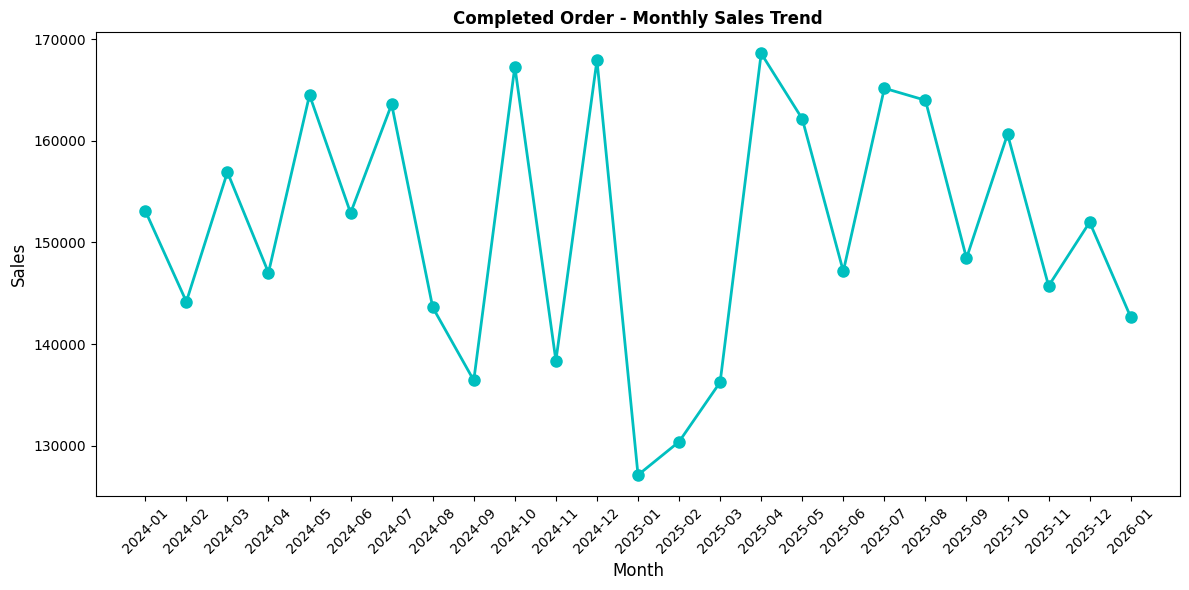

In [99]:
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['order_month'], monthly_revenue['item_subtotal'], 'co-',linewidth=2,markersize=8)
plt.title("Completed Order - Monthly Sales Trend",fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Sales",fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Monthly Sales Trend.png")
plt.show()

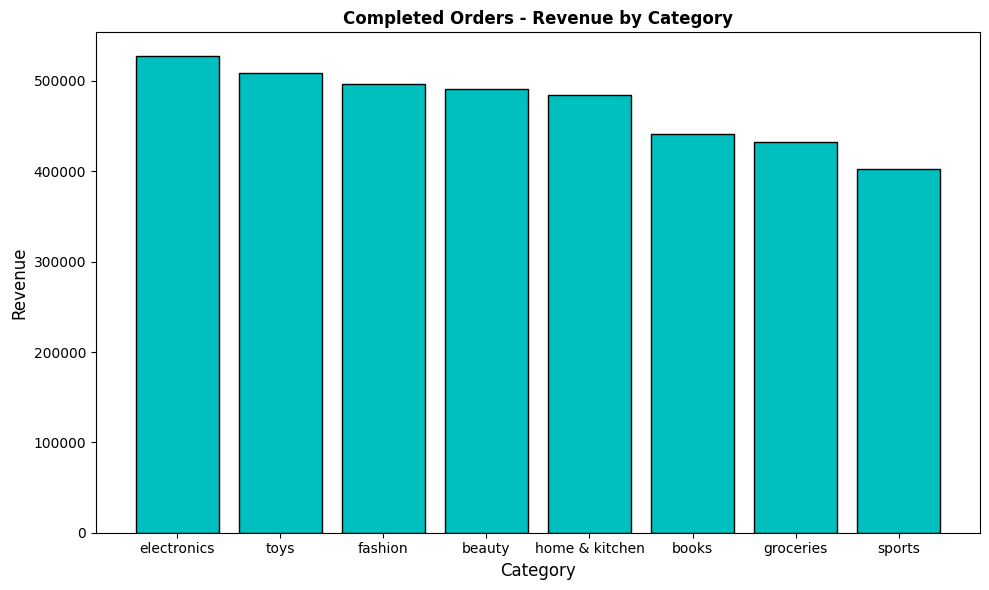

In [100]:
plt.figure(figsize=(10,6))
plt.bar(product_revenue['category_clean'], product_revenue['item_subtotal'], edgecolor='black', color='c')
plt.title("Completed Orders - Revenue by Category", fontweight ='bold')
plt.xlabel("Category", fontsize =12)
plt.ylabel("Revenue", fontsize = 12)
plt.tight_layout()
plt.savefig("Revenue by Category.png")
plt.show()

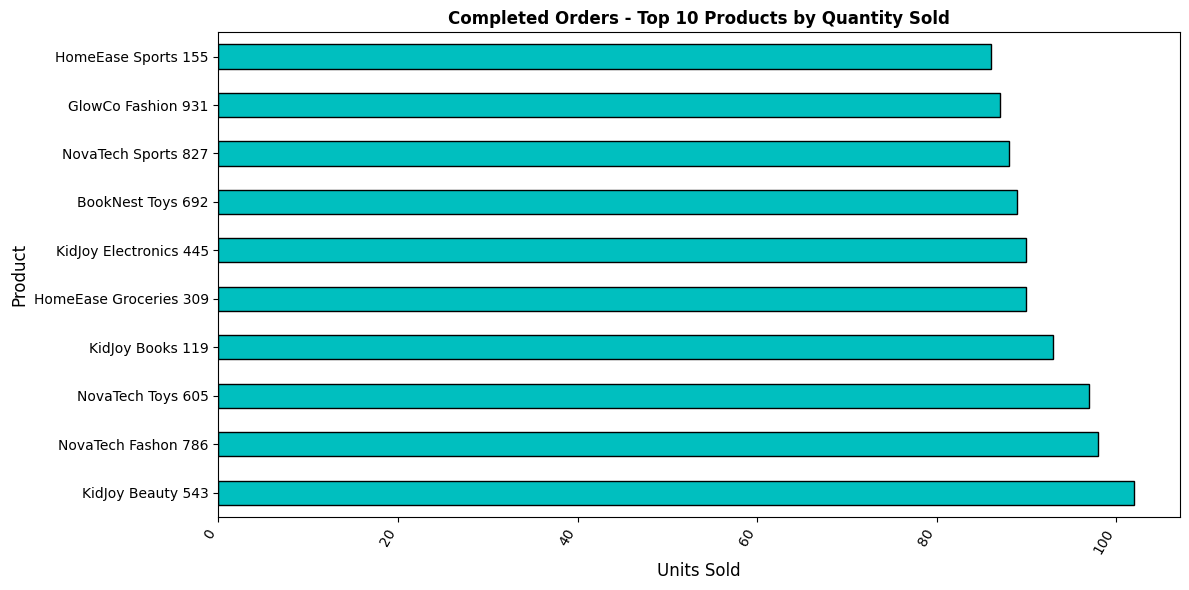

In [101]:
plt.figure(figsize=(12,6))
top_10_product_by_quantity.plot(kind='barh', color='c', edgecolor='black')
plt.title('Completed Orders - Top 10 Products by Quantity Sold', fontweight = 'bold')
plt.xlabel('Units Sold', fontsize = 12)
plt.ylabel('Product',fontsize = 12)
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.savefig("Top 10 Products by Quantity Sold.png")
plt.show()

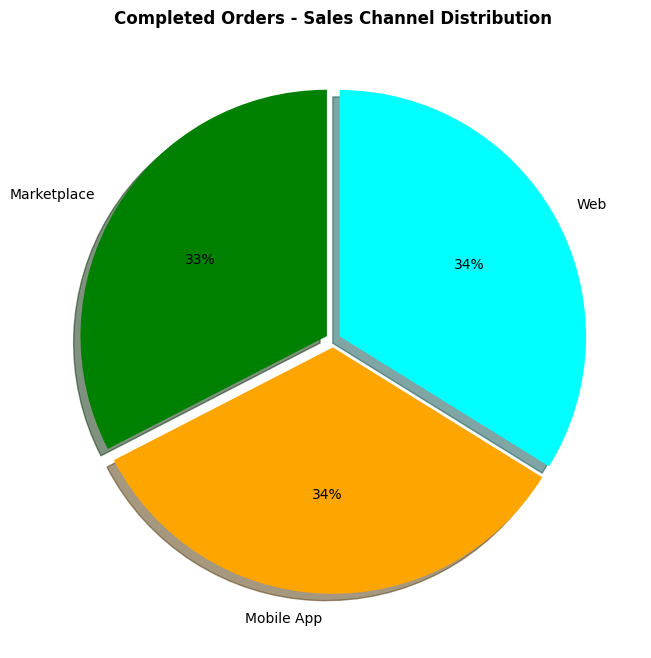

In [102]:
colors = ['green','orange','cyan']
explode = (0.03,0.03,0.03)
fig,ax=plt.subplots(figsize=(8,8))

ax.pie(sales_channel_rev,explode=explode, colors=colors, labels=sales_channel_rev.index,autopct='%1.0f%%',shadow=True,startangle=90)
ax.set_title("Completed Orders - Sales Channel Distribution", fontweight='bold')
plt.savefig("Sales Channel Distribution.png")
plt.show()


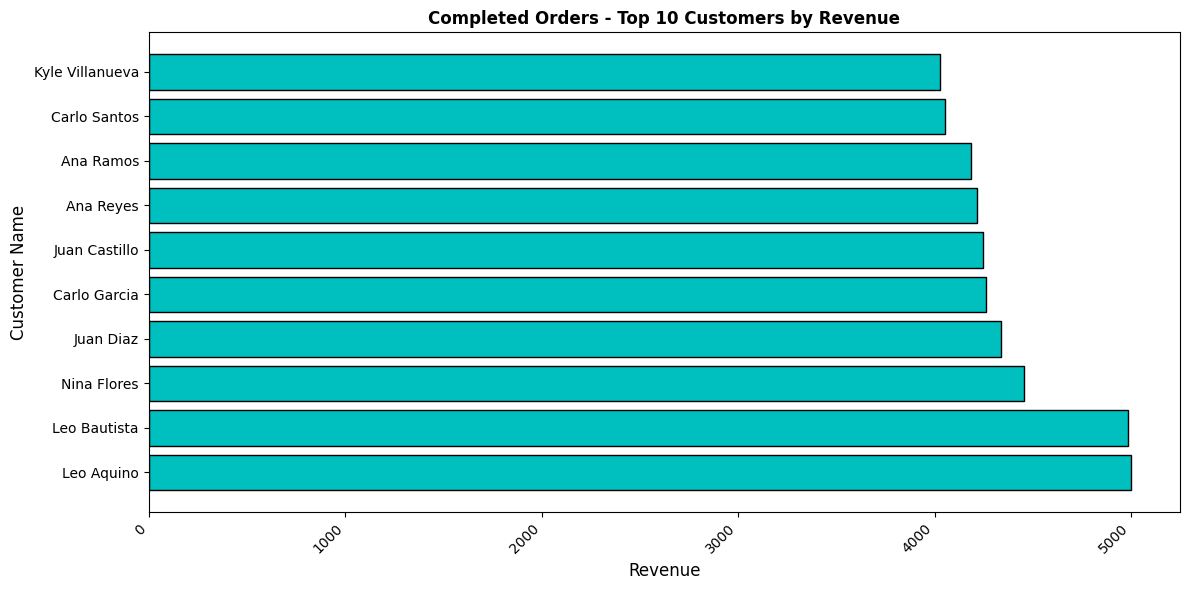

In [103]:
plt.figure(figsize=(12,6))
plt.barh(top10['full_name'],top10['item_subtotal'], color='c',edgecolor='black')
plt.title('Completed Orders - Top 10 Customers by Revenue', fontweight = 'bold')
plt.xlabel('Revenue', fontsize = 12)
plt.ylabel('Customer Name',fontsize = 12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Top 10 Customers by Revenue.png")
plt.show()

In [104]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [105]:
import matplotlib.cm as cm

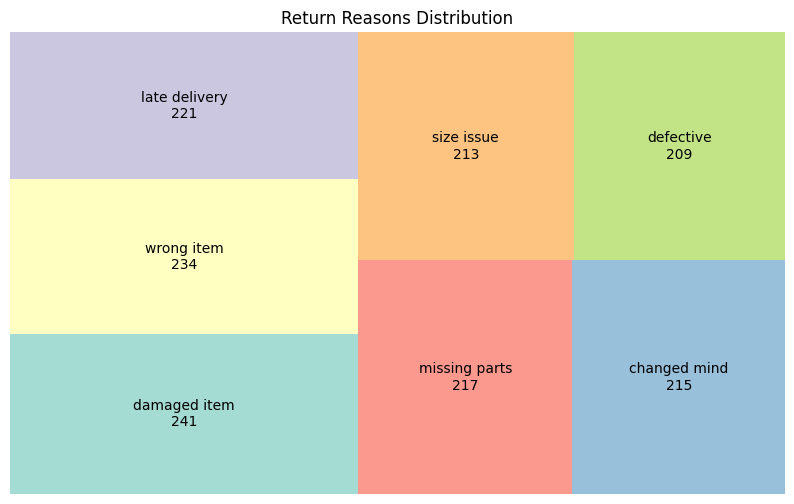

In [106]:
import squarify
data = reason_count
sizes = data['count']
labels = data['cleaned_reason'] + "\n" + data['count'].astype(str)
colors = cm.Set3(range(len(sizes)))
plt.figure(figsize=(10,6))
squarify.plot(
    sizes=sizes,
    label=labels,
    color=colors,
    alpha=0.8,
)
plt.axis('off')
plt.title('Return Reasons Distribution')
plt.savefig("Return Reasons Distribution.png")
plt.show()

In [107]:
customers.head()

,customer_id,first_name,last_name,gender,age,email,phone,region_code,region_name,city,barangay,signup_date,loyalty_tier,cleaned_gender,cleaned_age,cleaned_email,email_valid,cleaned_phone,signup_month
0,CUST000001,Grace,DelosReyes,NaN,20.0,grace.delosreyes95@outlook.com,9.196001e+09,Region III,Central Luzon,Angeles,Brgy 1,2025-12-31,Bronze,unknown,20.0,grace.delosreyes95@outlook.com,True,91960013380,2025-12
1,CUST000002,Ana,Ramos,Female,35.0,ana.ramos@companymail.ph,9.026542e+09,CARAGA,Caraga,Butuan,Brgy 9,2025-02-08,Bronze,female,35.0,ana.ramos@companymail.ph,True,90265423510,2025-02
2,CUST000003,Arvin,Navarro,Male,14.0,arvin.navarrooutlook.com,9.161850e+09,NCR,Metro Manila,Pasig,Brgy 2,2023-09-10,Bronze,male,14.0,NaN,False,91618495930,2023-09
3,CUST000004,Kyle,Rivera,F,26.0,kyle.rivera13@outlook.com,9.752553e+09,Region III,Central Luzon,Angeles,Brgy 1,2024-11-17,NaN,female,26.0,kyle.rivera13@outlook.com,True,97525534190,2024-11
4,CUST000005,Juan,Mendoza,Male,29.0,juan.mendoza@gmail.com,9.350306e+09,Region III,Central Luzon,Angeles,Brgy 9,2023-01-21,Gold,male,29.0,juan.mendoza@gmail.com,True,93503056410,2023-01


In [108]:
products.head()

,product_id,product_name,brand,category,unit_cost,unit_price,stock_qty,uom,launch_date,category_clean
0,PROD00001,KidJoy Beauty 963,KidJoy,Beauty,44.17,64.50,125.0,pc,2022-01-18,beauty
1,PROD00002,HomeEase Home 368,HomeEase,Home and Kitchen,37.18,70.39,131.0,pcs,2022-11-25,home & kitchen
2,PROD00003,FreshCart Fashion 911,FreshCart,Fashion,46.29,70.26,41.0,piece,2023-09-04,fashion
3,PROD00004,NovaTech Toys 753,NovaTech,Toys,43.66,62.46,149.0,pcs,2023-08-12,toys
4,PROD00005,GlowCo Books 916,GlowCo,Books,64.59,82.02,162.0,bottle,2024-05-12,books


In [109]:
orders.head()


,order_id,customer_id,order_datetime,order_status,sales_channel,shipping_method,discount_pct,shipping_fee,cleaned_order_status,cleaned_sales_channel,order_month
0,ORD0000001,CUST000839,2025-11-07 17:02:00,Cancelled,Marketplace,Standard,0.074,102.68,cancelled,marketplace,2025-11
2,ORD0000003,CUST000720,2025-08-08 04:59:00,Completed,Web,Standard,0.137,103.83,completed,web,2025-08
3,ORD0000004,CUST002515,2025-10-14 12:56:00,Completed,Web,Pickup,0.005,112.69,completed,web,2025-10
4,ORD0000005,CUST001544,2024-05-30 04:56:00,Completed,Marketplace,Pickup,NaN,111.73,completed,marketplace,2024-05
5,ORD0000006,CUST001560,2024-08-13 18:42:00,Shipped,Mobile App,Pickup,0.089,86.54,shipped,mobile app,2024-08


In [110]:
order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price_at_purchase,unit_price,final_unit_price,item_subtotal
0,ITEM000000001,ORD0000001,PROD00513,2,120.67,120.67,120.67,241.34
1,ITEM000000002,ORD0000002,PROD00124,2,83.58,83.58,83.58,167.16
2,ITEM000000003,ORD0000002,PROD00631,2,46.96,46.96,46.96,93.92
3,ITEM000000004,ORD0000002,PROD00136,1,100.59,100.59,100.59,100.59
4,ITEM000000005,ORD0000002,PROD00090,1,109.18,109.18,109.18,109.18


In [111]:
payments.head()

,payment_id,order_id,payment_method,payment_status,payment_date,amount_paid
0,PAY0000001,ORD0000001,GCash,Paid,2024-05-09,2822.72
2,PAY0000003,ORD0000003,GCash,Paid,2025-06-10,1983.66
3,PAY0000004,ORD0000004,PayMaya,Failed,2025-06-21,1765.99
4,PAY0000005,ORD0000005,COD,Pending,NaT,1477.53
5,PAY0000006,ORD0000006,COD,Failed,2025-11-22,1422.10


In [112]:
shipments.head()


,shipment_id,order_id,courier,tracking_no,shipment_status,ship_date,delivered_date,cleaned_shipment_status
0,SHP0000001,ORD0000001,J&T,HLI2ORMO9V4O,Delivered,2025-09-05,2025-09-06,delivered
2,SHP0000003,ORD0000003,2GO,LHLXVJF18MQB,Delivered,2025-07-23,NaT,delivered
3,SHP0000004,ORD0000004,GrabExpress,RXUNTQ7WKL5B,Delivered,2025-01-21,NaT,delivered
4,SHP0000005,ORD0000005,2GO,XQLUM80WBUSJ,In Transit,2025-09-21,NaT,in transit
5,SHP0000006,ORD0000006,LBC,XVBPOV7PESZ8,Delivered,2024-01-10,NaT,delivered


In [113]:
returns.head()


,return_id,order_id,return_request_date,reason,refunded_flag,refund_amount,cleaned_reason
0,RET000001,ORD0008752,2025-01-09,Defective,No,NaN,defective
1,RET000002,ORD0007359,2025-07-20,Wrong item,NaN,650.28,wrong item
2,RET000003,ORD0009041,NaT,Size issue,Yes,NaN,size issue
3,RET000004,ORD0000227,2025-03-04,Late delivery,Partial,NaN,late delivery
4,RET000005,ORD0005754,2025-04-24,Size issue,Yes,713.39,size issue
